# SEIHRV Simulations

I want to simulate 9 different situations, with varying efficacy and vaccine deployment. 

For a total simulation period of 100 days, I will look at days 20, 40, 60.

Minimum efficacy for vaccine is ~50%, so look at 50%, 70%, 90% efficacies.

So the 9 simulations are:

- [50% efficacy](#50) 
  > •[T = 20 days](#50_20days)  
  > •[T = 40 days](#50_40days)  
  > •[T = 60 days](#50_60days) 
   
- [70% efficacy](#70)
  > •[T = 20 days](#70_20days)  
  > •[T = 40 days](#70_40days)  
  > •[T = 60 days](#70_60days) 
  
- [90% efficacy](#90)
  > •[T = 20 days](#90_20days)  
  > •[T = 40 days](#90_40days)  
  > •[T = 60 days](#90_60days) 

## General Simulation Code

Nothing below should vary for the different vaccine situations.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

# Rates
beta = 1.4247 
epsilon = 1/5.28
gamma = 1/5 
delta = 1/8.78 
tau = 0.25 
rho = 0.1
omega = 1/100
d = 0.6
h = 0.15 

# Population sizes
N = 100000   #total
S0 = 99900
E0 = 50
I_S0 = 25
I_A0 = 25
H0 = 0
R0 = 0
V_I0 = 0
V_S0 = 0

# Time values
t_start = 0
days = 100
t_step=1.0

InitialVals = [S0, E0, I_S0, I_A0, H0, R0, V_I0, V_S0]

# SEIHR model with vaccination set to 0
def SEIHRmodel(IVS,time):  
    
    FOI = beta*(tau*IVS[3] + IVS[2] + rho*IVS[4])
    
    S = - FOI * IVS[0]/N + omega*IVS[5]
    E = FOI * IVS[0]/N - epsilon*IVS[1]
    I_S = epsilon*d*IVS[1] - gamma*IVS[2]
    I_A = epsilon*(1 - d)*IVS[1] - gamma*IVS[3]
    H = gamma*h*IVS[2] - delta*IVS[4]
    R = delta*IVS[4] + gamma*(1 - h)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    V_I = 0
    V_S = 0
    
    Y = [S, E, I_S, I_A, H, R, V_I, V_S]
    return(Y) 

# SEIHRV model, adding vaccine
def SEIHRVmodel(IVS,time):  
    
    FOI = beta*(tau*IVS[3] + IVS[2] + rho*IVS[4])
    
    S = - FOI * IVS[0]/N + omega*IVS[5] - sigma*IVS[0]
    E = FOI * (IVS[0]+IVS[7])/N - epsilon*IVS[1]
    I_S = epsilon*d*IVS[1] - gamma*IVS[2]
    I_A = epsilon*(1 - d)*IVS[1] - gamma*IVS[3]
    H = gamma*h*IVS[2] - delta*IVS[4]
    R = delta*IVS[4] + gamma*(1 - h)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    V_I = sigma*eta*IVS[0]
    V_S = sigma*(1-eta)*IVS[0] - FOI*IVS[7]/N
    
    Y = [S, E, I_S, I_A, H, R, V_I, V_S]
    return(Y) 

def SEIHRVsimulator(sigma, eta, vaccinetime): #simulating changes in vaccination rate/efficacy/deployment 
    t1 = np.arange(t_start, vaccinetime, t_step)
    t2 = np.arange(vaccinetime - t_step, days + t_step, t_step)

    values1 = spi.odeint(SEIHRmodel, InitialVals, t1)
    values2 = spi.odeint(SEIHRVmodel, values1[-1], t2)


    total_values = np.concatenate((values1, values2[1:]), axis = 0)

    total_vaccinated = total_values[:,6] + total_values[:,7]

    # Plotting:
    plt.figure(figsize=(15, 20))

    plt.subplot(511)
    plt.plot(total_values[:,0], 'purple', linewidth = 3)
    plt.axvline(vaccinetime, color = 'grey', linestyle='dashed', label = 'Vaccine Rollout')
    plt.title('SEIHRV Model', fontsize=25)
    plt.legend(loc=0)
    plt.ylabel('Susceptibles', fontsize=15)
    
    plt.subplot(512)
    plt.plot(total_values[:,1], 'cornflowerblue', linewidth = 3, label='Exposed')
    plt.plot(total_values[:,2], 'firebrick', linewidth = 3, label = 'Infectious symptomatic')
    plt.plot(total_values[:,3], 'lightcoral', linewidth = 3, label = 'Infectious asymptomatic')
    plt.axvline(vaccinetime, color = 'grey', linestyle='dashed')
    plt.legend(loc=0)
    plt.ylabel('Infected', fontsize=15)
    
    plt.subplot(513)
    plt.plot(total_values[:,5], 'green', linewidth = 3, label='Removed')
    plt.axvline(vaccinetime, color = 'grey', linestyle='dashed')
    plt.ylabel('Removed', fontsize=15)
    
    plt.subplot(514)
    plt.plot(total_values[:,4], 'orange', linewidth = 3, label = 'Hospitalised')
    plt.axvline(vaccinetime, color = 'grey', linestyle='dashed')
    plt.ylabel('Hospitalisations', fontsize=15)
    
    plt.subplot(515)
    plt.plot(total_vaccinated, 'indigo', linewidth = 3, label='Total Vaccinated')
    plt.plot(total_values[:,6], 'thistle', linewidth = 2, linestyle = "--", label='Vaccinated Immune')
    plt.plot(total_values[:,7], 'darkviolet', linewidth = 2, linestyle = "--", label='Vaccinated Susceptible')
    plt.axvline(vaccinetime, color = 'grey', linestyle='dashed')
    plt.legend(loc=0)
    plt.xlabel('Time (days)', fontsize=15)
    plt.ylabel('Vaccinations', fontsize = 15)
    
    plt.show()

## 50% Efficacy  <a id="50"></a>

### T = 20 Days <a id="50_25days"></a>

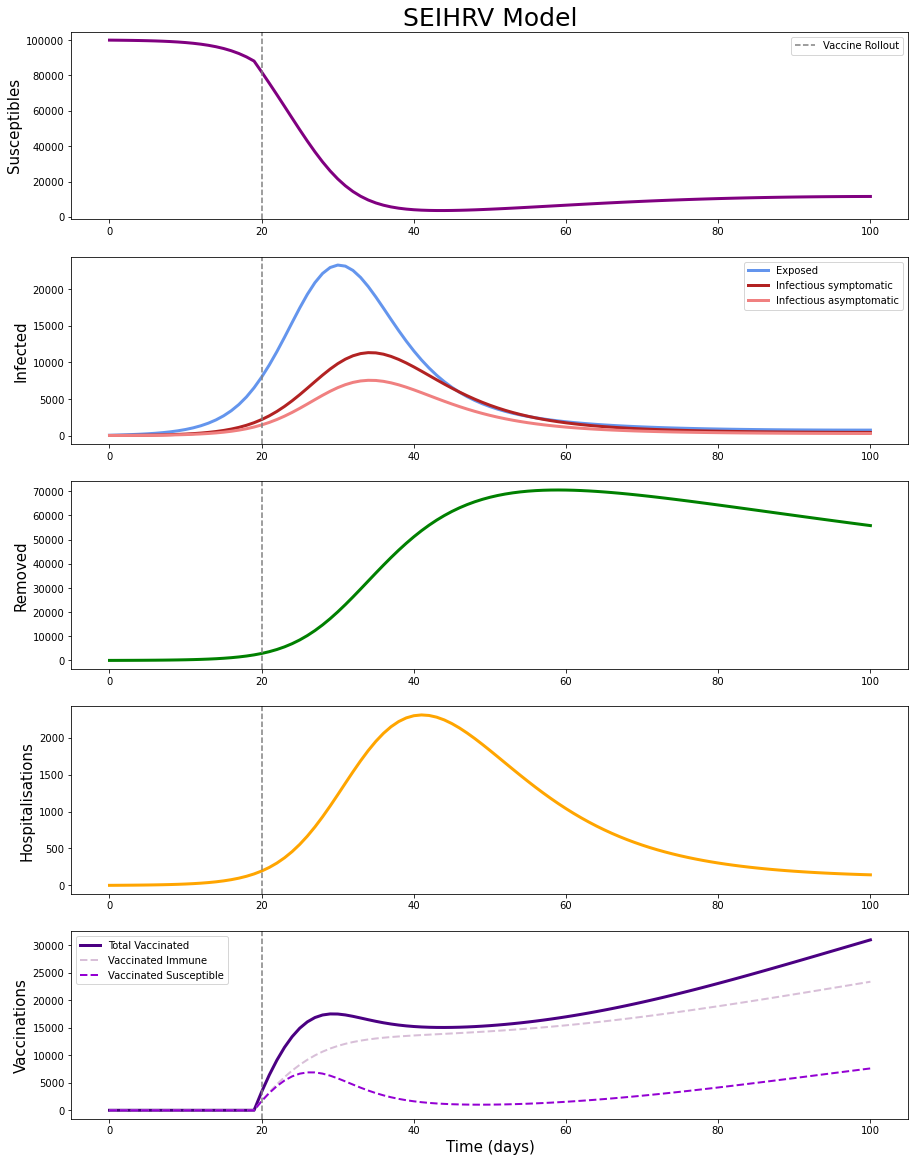

In [28]:
sigma = 0.04  
eta = 0.5
vaccinetime = 20 

SEIHRVsimulator(sigma, eta, vaccinetime)

### T = 40 Days <a id="50_40days"></a>

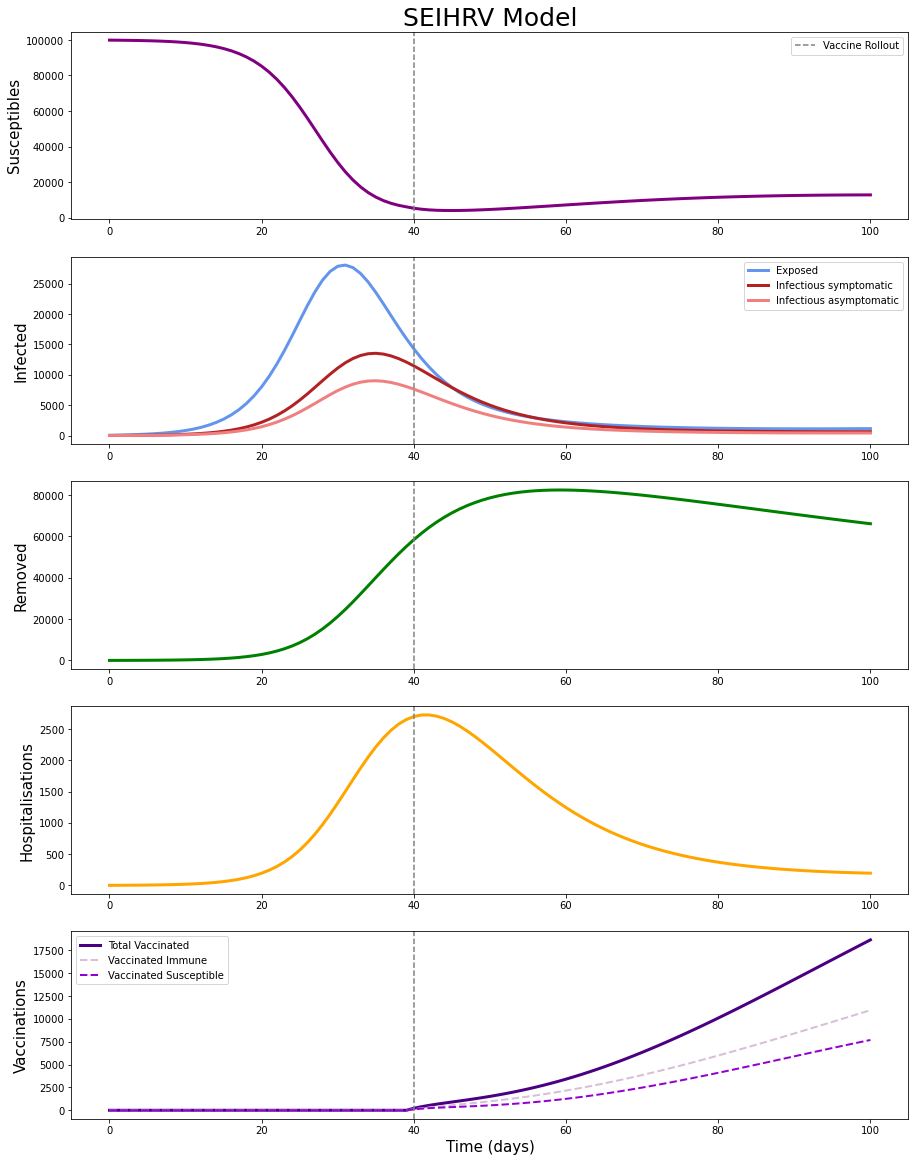

In [19]:
sigma = 0.04  
eta = 0.5
vaccinetime = 40

SEIHRVsimulator(sigma, eta, vaccinetime)

### T = 60 Days <a id="50_60days"></a>

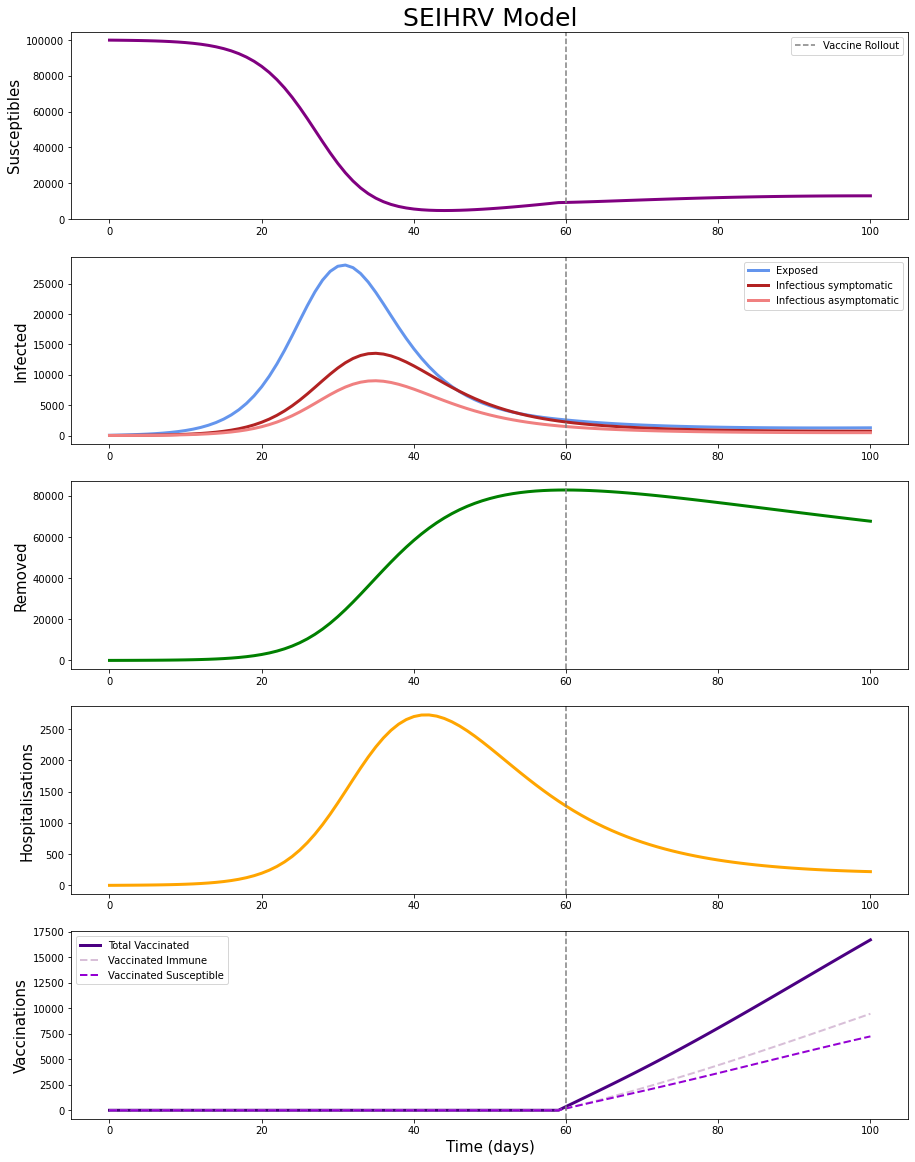

In [20]:
sigma = 0.04  
eta = 0.5
vaccinetime = 60

SEIHRVsimulator(sigma, eta, vaccinetime)

## 70% Efficacy  <a id="70"></a>

### T = 20 Days <a id="70_20days"></a>

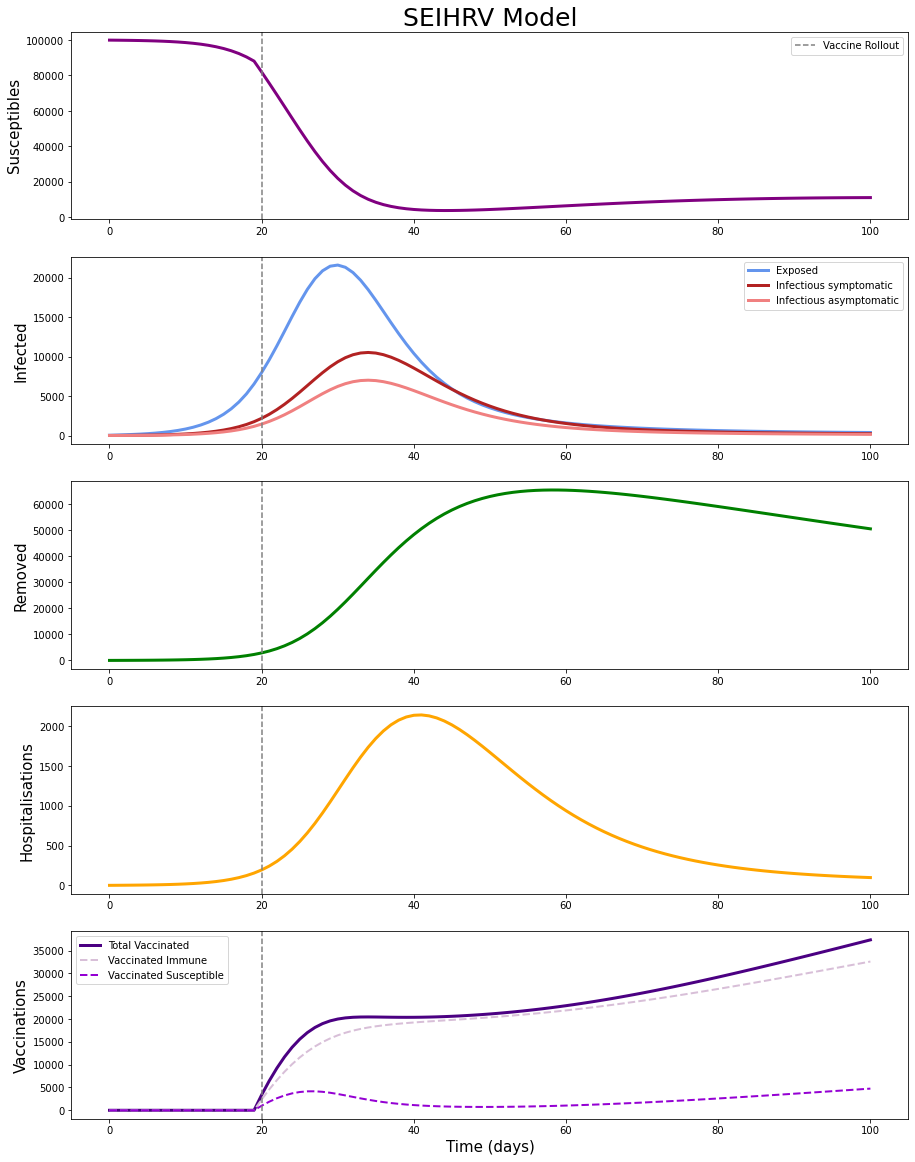

In [21]:
sigma = 0.04  
eta = 0.7
vaccinetime = 20

SEIHRVsimulator(sigma, eta, vaccinetime)

### T = 40 Days <a id="70_40days"></a>

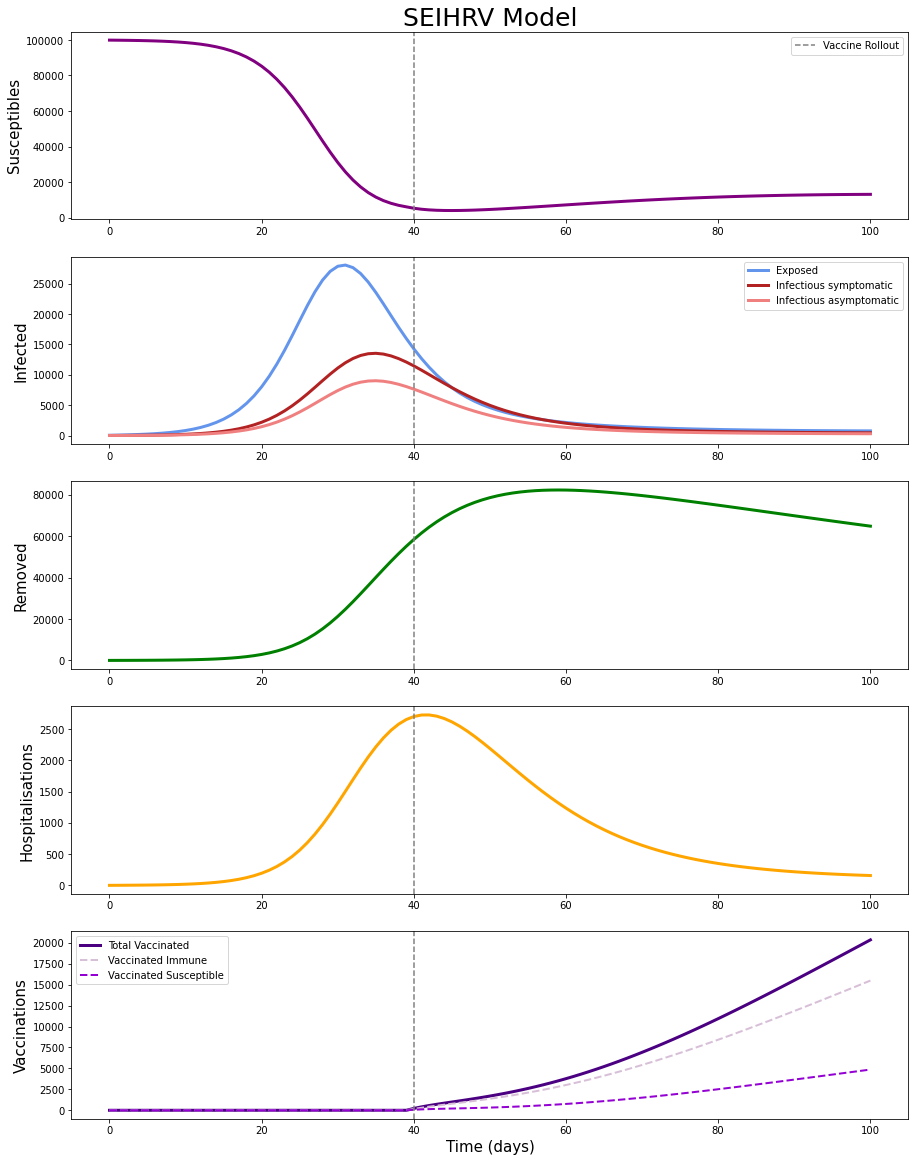

In [22]:
sigma = 0.04  
eta = 0.7
vaccinetime = 40

SEIHRVsimulator(sigma, eta, vaccinetime)

### T = 60 Days <a id="70_60days"></a>

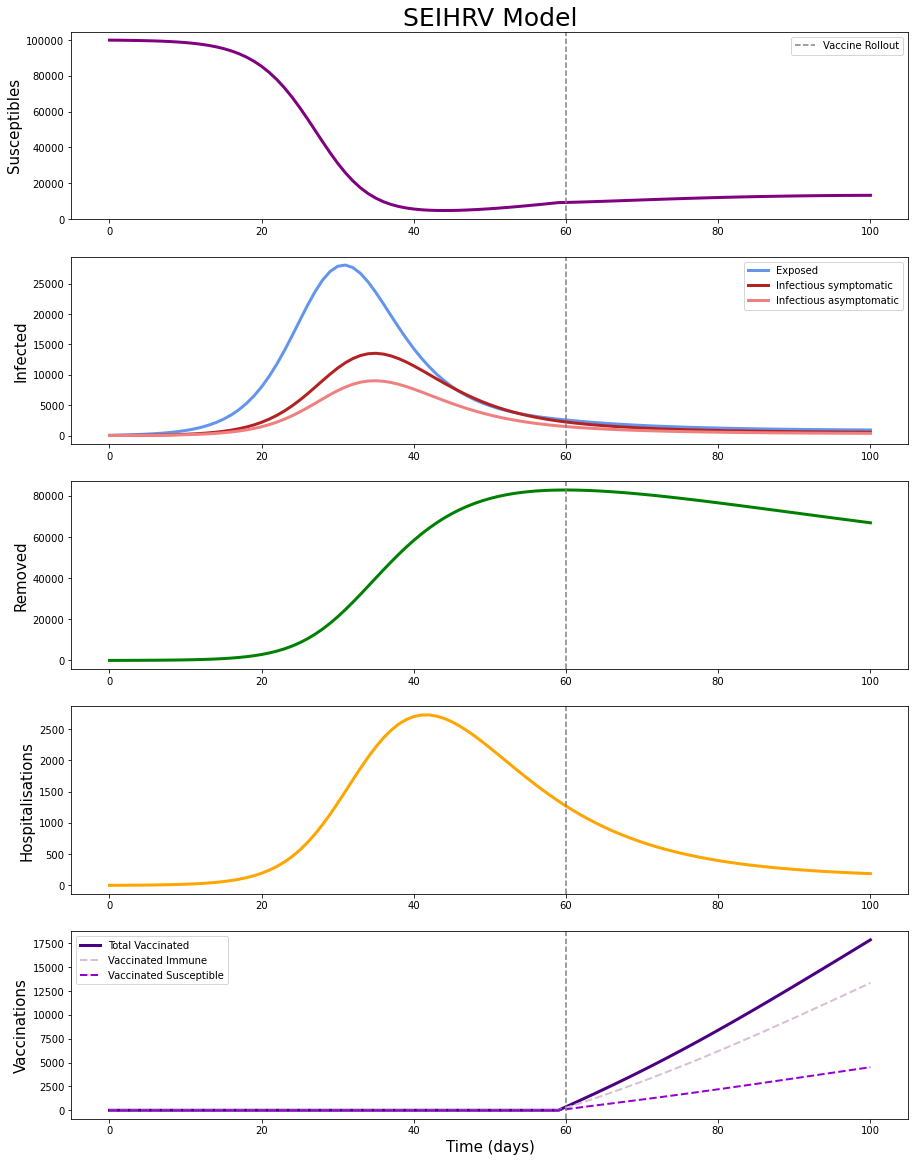

In [23]:
sigma = 0.04  
eta = 0.7
vaccinetime = 60

SEIHRVsimulator(sigma, eta, vaccinetime)

## 90% Efficacy  <a id="90"></a>

### T = 20 Days <a id="90_20days"></a>

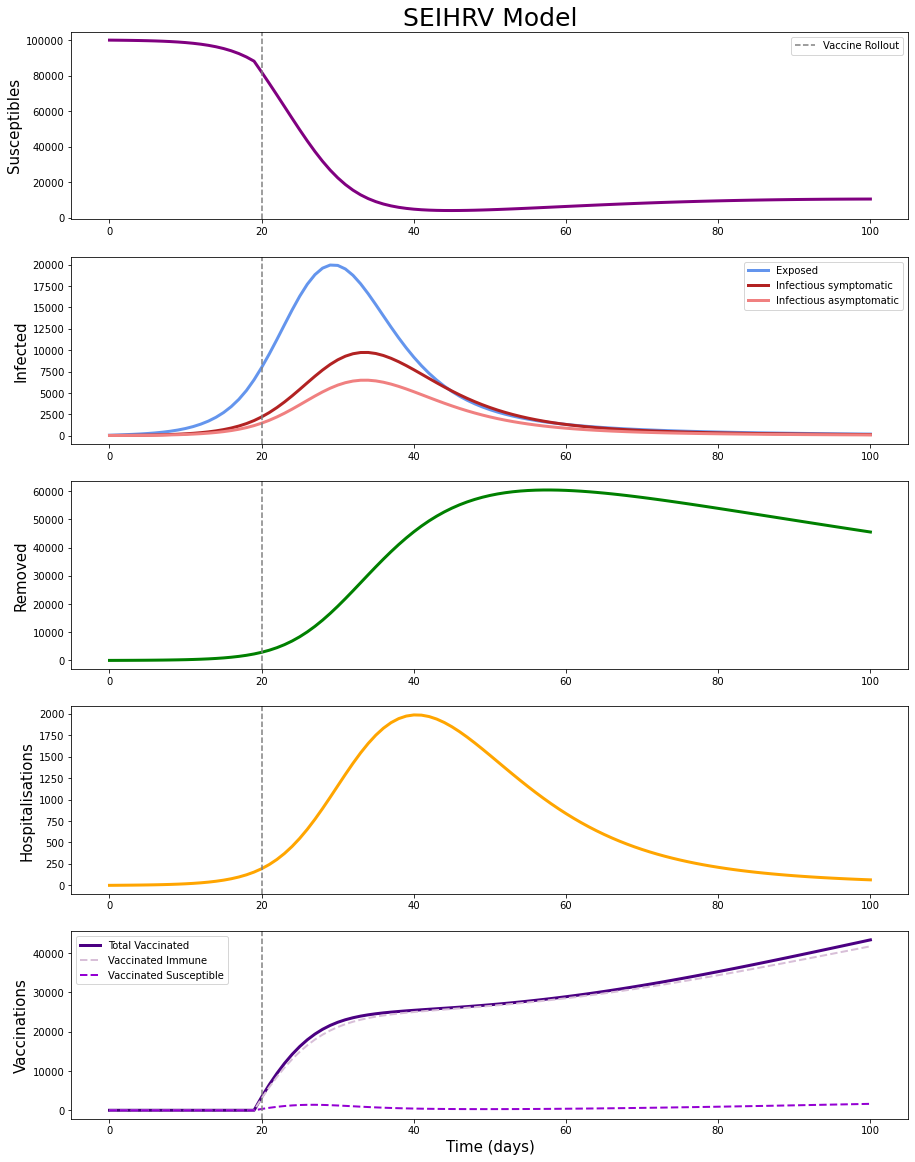

In [24]:
sigma = 0.04  
eta = 0.9
vaccinetime = 20

SEIHRVsimulator(sigma, eta, vaccinetime)

### T = 40 Days <a id="90_40days"></a>

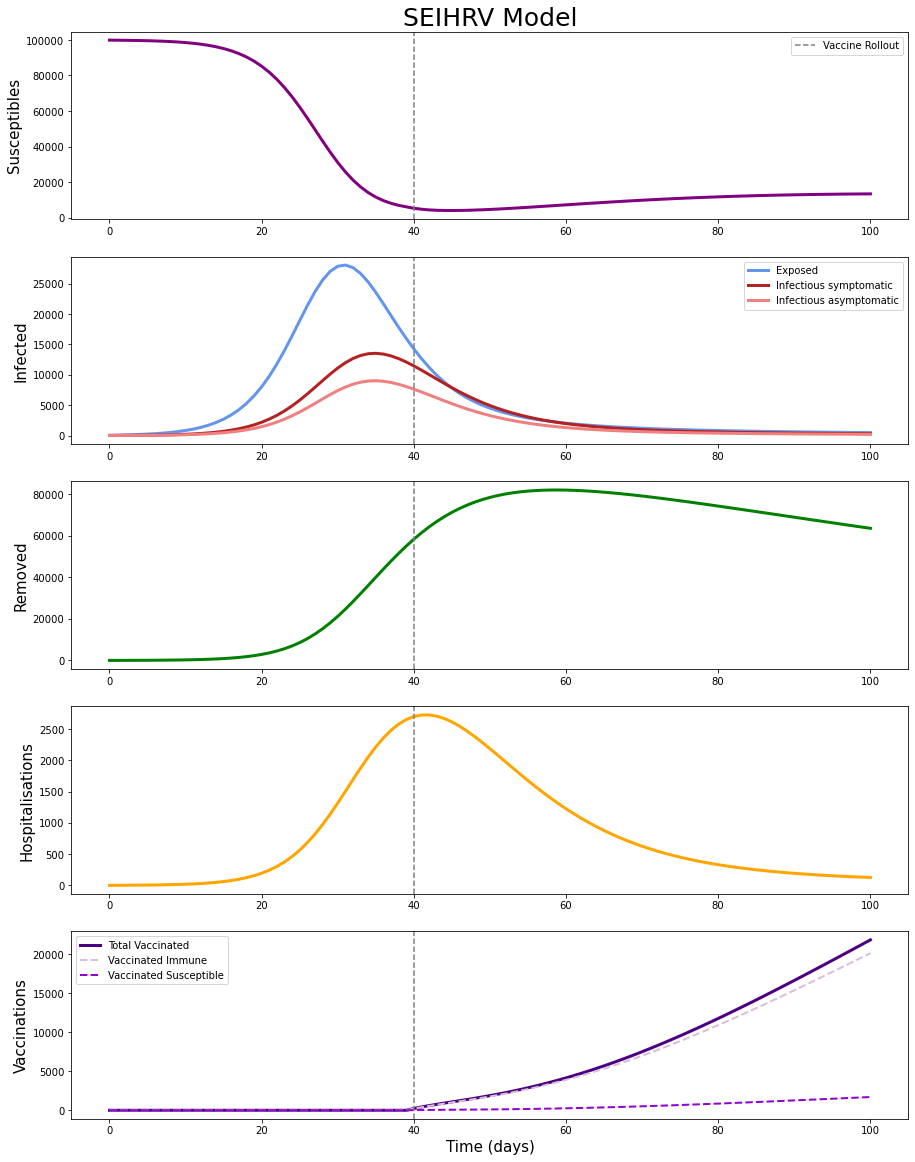

In [25]:
sigma = 0.04  
eta = 0.9
vaccinetime = 40

SEIHRVsimulator(sigma, eta, vaccinetime)

### T = 60 Days <a id="90_60days"></a>

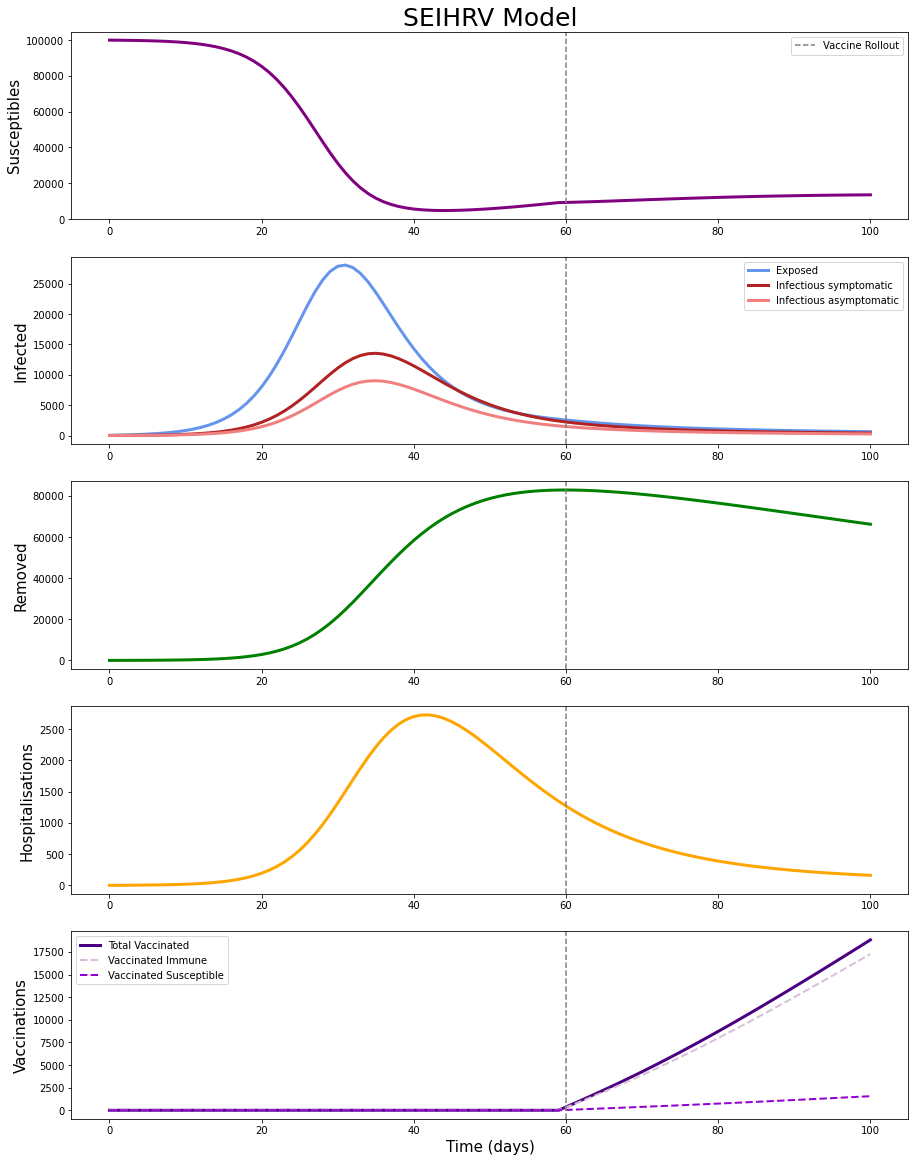

In [26]:
sigma = 0.04  
eta = 0.9
vaccinetime = 60

SEIHRVsimulator(sigma, eta, vaccinetime)